# 第072课 密度与层次聚类

本Notebook先复算数值，再解释图像。请从头执行全部单元。生成标签不参与拟合；源CSV可按固定种子重建。

In [1]:
import os
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('OMP_NUM_THREADS', '1')
import numpy as np
from pathlib import Path
from IPython.display import display, Image
from common import ROOT, load_data
from experiment import run
report = run()
print('Unit', report['unit'], 'report recomputed')

Unit 072 report recomputed


## 数据与边界
数据检查同时比较散列与生成字节。以下只展示行数，不把生成分组作为算法输入。

In [2]:
data = load_data()
for name, values in data.items():
    print(name, len(values['id']), 'rows')

rings 300 rows
unequal 265 rows
bridge 197 rows


## 核心与边界手算
邻域包含自己。边界点能被接纳，但不能作为扩展链的中间核心点。

In [3]:
for x, count, core, label in zip(report['hand_density']['X'], report['hand_density']['neighbor_counts'], report['hand_density']['core'], report['hand_density']['labels']):
    print(x[0], 'neighbors', count, 'core', core, 'label', label)

0.0 neighbors 4 core True label 0
0.1 neighbors 4 core True label 0
0.2 neighbors 4 core True label 0
0.3 neighbors 5 core True label 0
0.55 neighbors 2 core False label 0
1.5 neighbors 1 core False label -1


## 层次链接
树状图纵轴依赖linkage，不能直接互相比大小。

In [4]:
for method, Z in report['hand_hierarchy']['merges'].items():
    print(method, np.array(Z), sep='\n')

single
[[0. 1. 1. 2.]
 [2. 3. 3. 2.]
 [4. 5. 3. 4.]]
complete
[[0. 1. 1. 2.]
 [2. 3. 3. 2.]
 [4. 5. 7. 4.]]
average
[[0. 1. 1. 2.]
 [2. 3. 3. 2.]
 [4. 5. 5. 4.]]


## 三类反例
同时读簇数、大小、噪声比例，避免用单一数字宣称成功。

In [5]:
for scenario in report['scenarios']:
    print('\n' + scenario['name'])
    for name, result in scenario['methods'].items():
        print(name, 'clusters', result['clusters'], 'sizes', result['sizes'], 'noise', round(result['noise_fraction'], 4))


rings
kmeans clusters 2 sizes [149, 151] noise 0.0
single clusters 2 sizes [150, 150] noise 0.0
complete clusters 2 sizes [174, 126] noise 0.0
average clusters 2 sizes [51, 249] noise 0.0
ward clusters 2 sizes [107, 193] noise 0.0
dbscan_0.1 clusters 1 sizes [150] noise 0.5
dbscan_0.13 clusters 6 sizes [150, 6, 6, 6, 6, 6] noise 0.4
dbscan_0.24 clusters 2 sizes [150, 150] noise 0.0

unequal
kmeans clusters 2 sizes [121, 144] noise 0.0
single clusters 2 sizes [2, 263] noise 0.0
complete clusters 2 sizes [121, 144] noise 0.0
average clusters 2 sizes [144, 121] noise 0.0
ward clusters 2 sizes [113, 152] noise 0.0
dbscan_0.13 clusters 4 sizes [100, 6, 12, 10] noise 0.517
dbscan_0.24 clusters 2 sizes [101, 112] noise 0.1962
dbscan_0.4 clusters 1 sizes [256] noise 0.034

bridge
kmeans clusters 2 sizes [97, 100] noise 0.0
single clusters 2 sizes [1, 196] noise 0.0
complete clusters 2 sizes [94, 103] noise 0.0
average clusters 2 sizes [93, 104] noise 0.0
ward clusters 2 sizes [93, 104] noise 

## 从本次结果重新绘图
图像由当前计算报告产生并嵌入输出，离线打开Notebook仍可看见。

01_rings_comparison.png


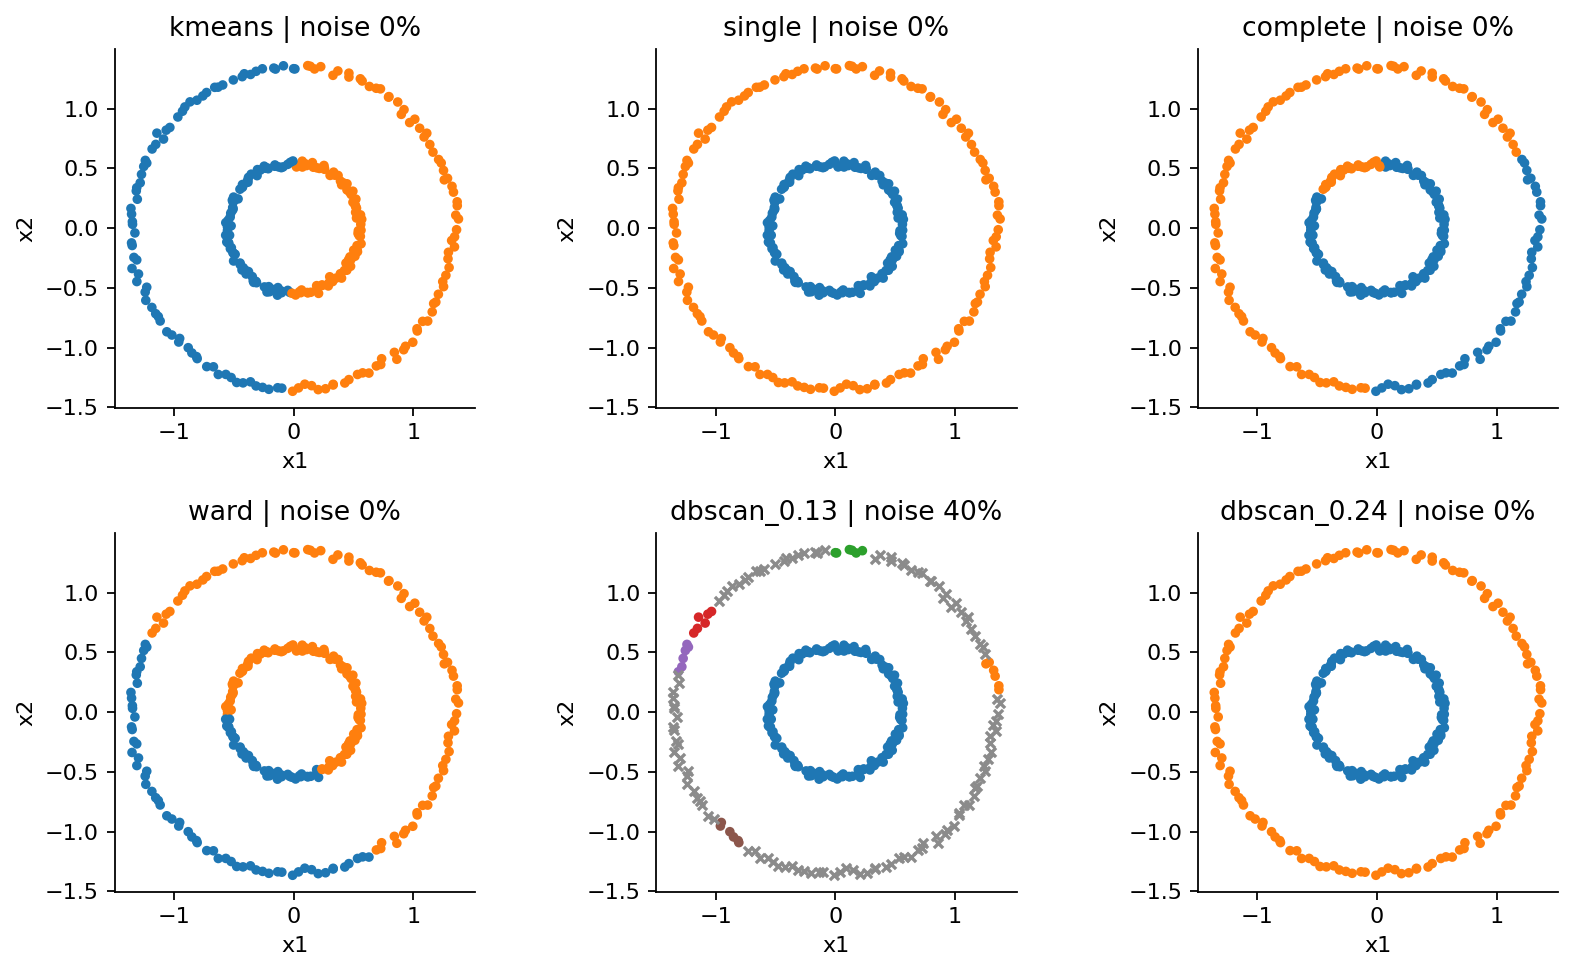

02_unequal_comparison.png


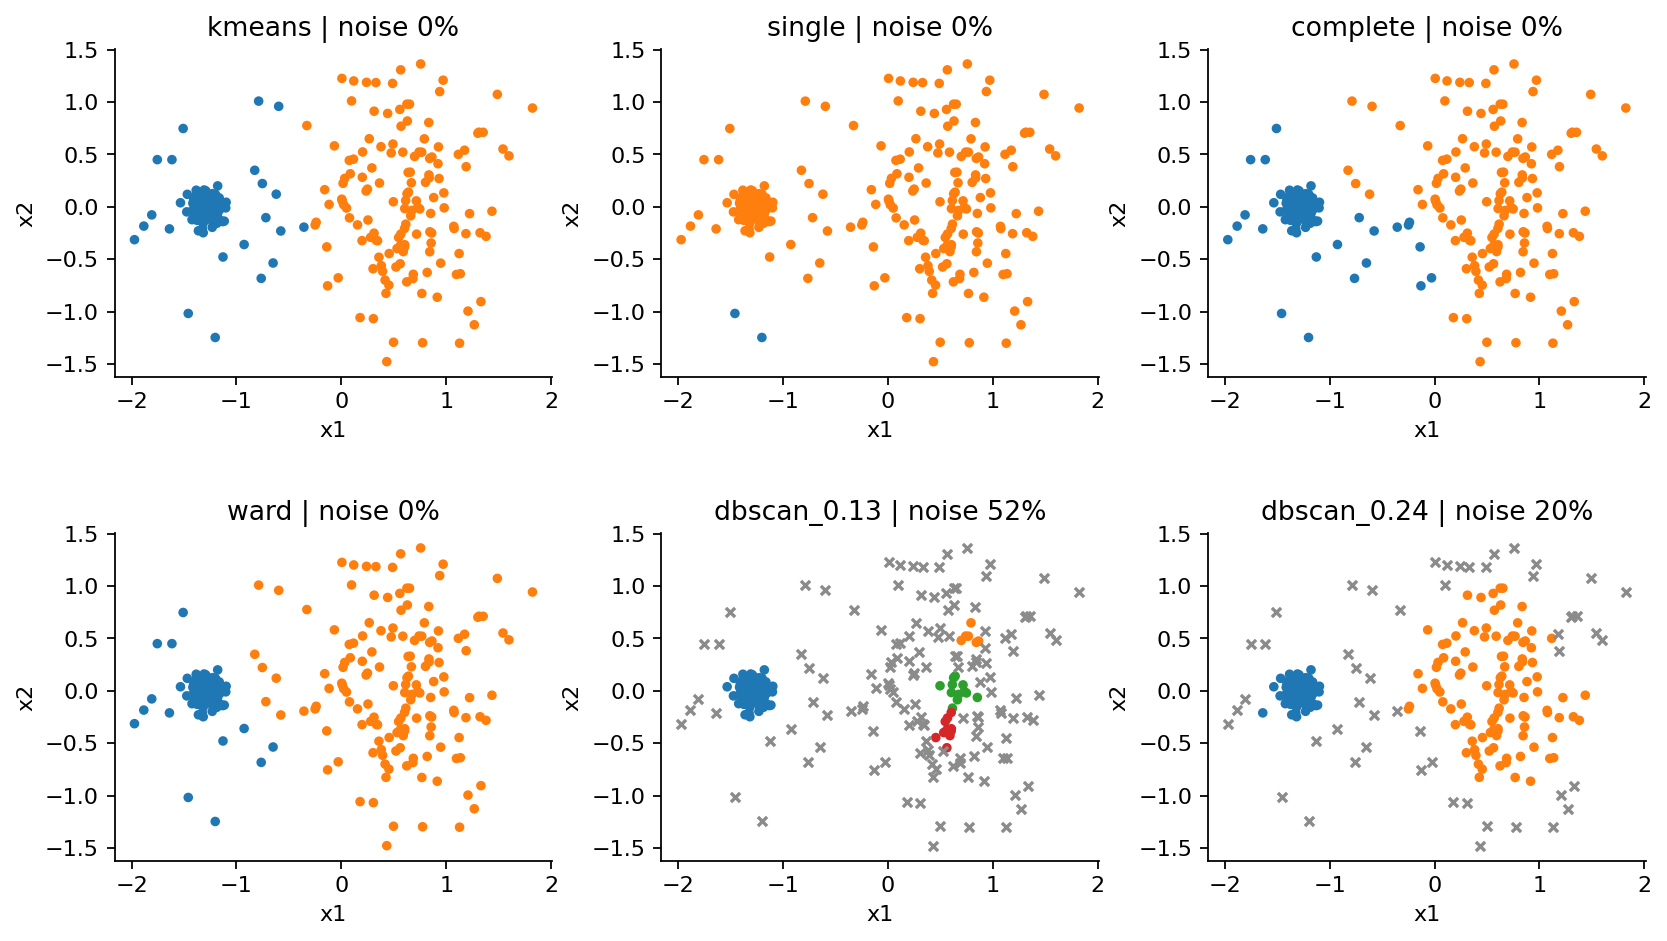

03_bridge_comparison.png


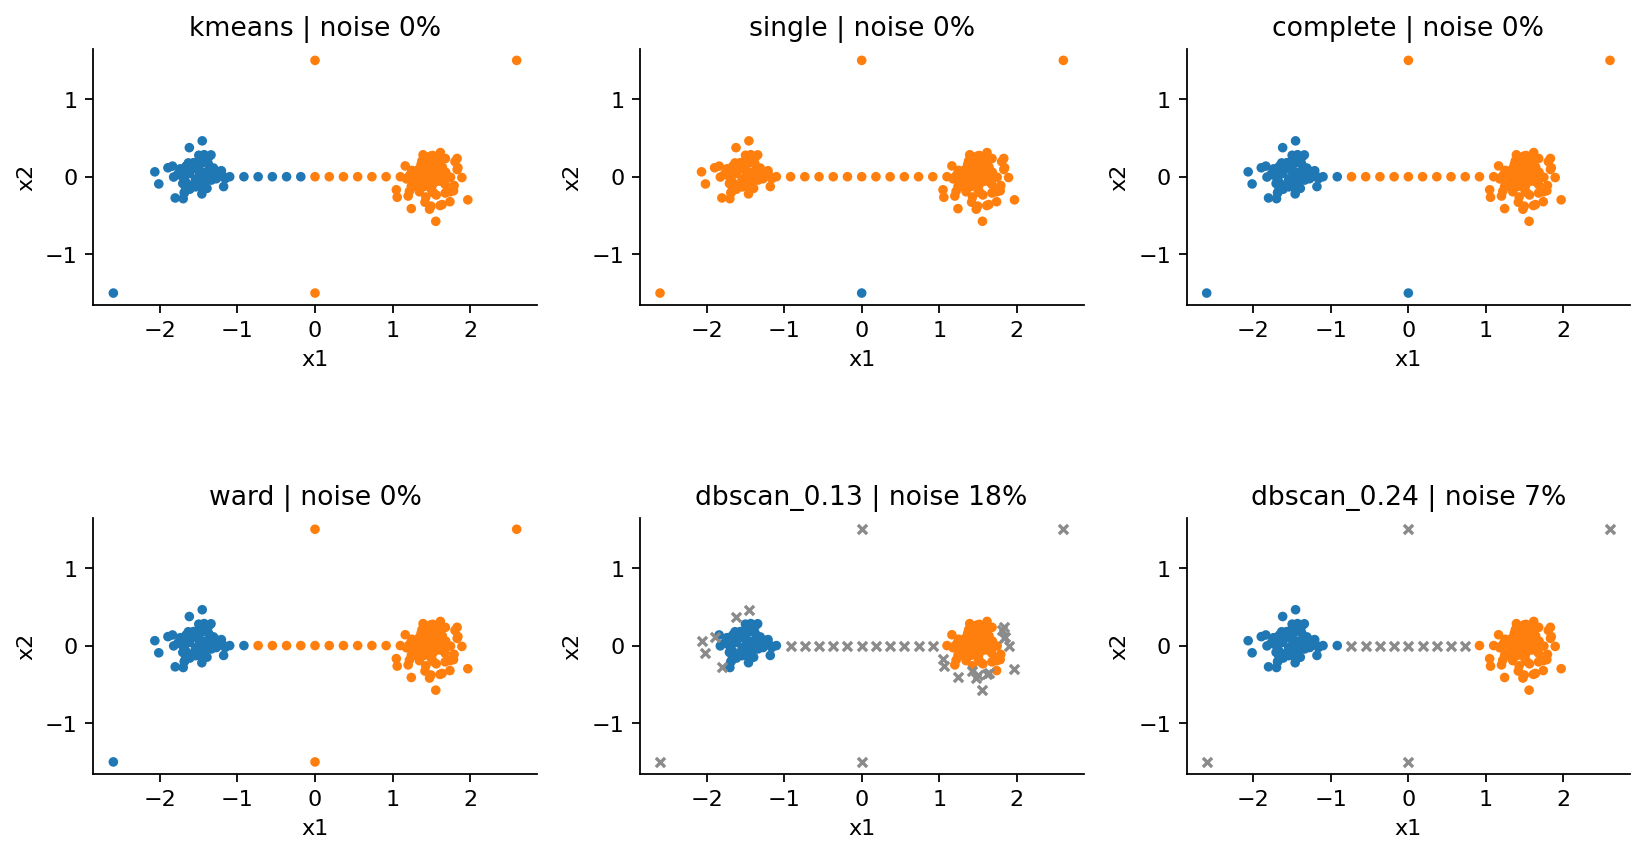

04_dendrograms.png


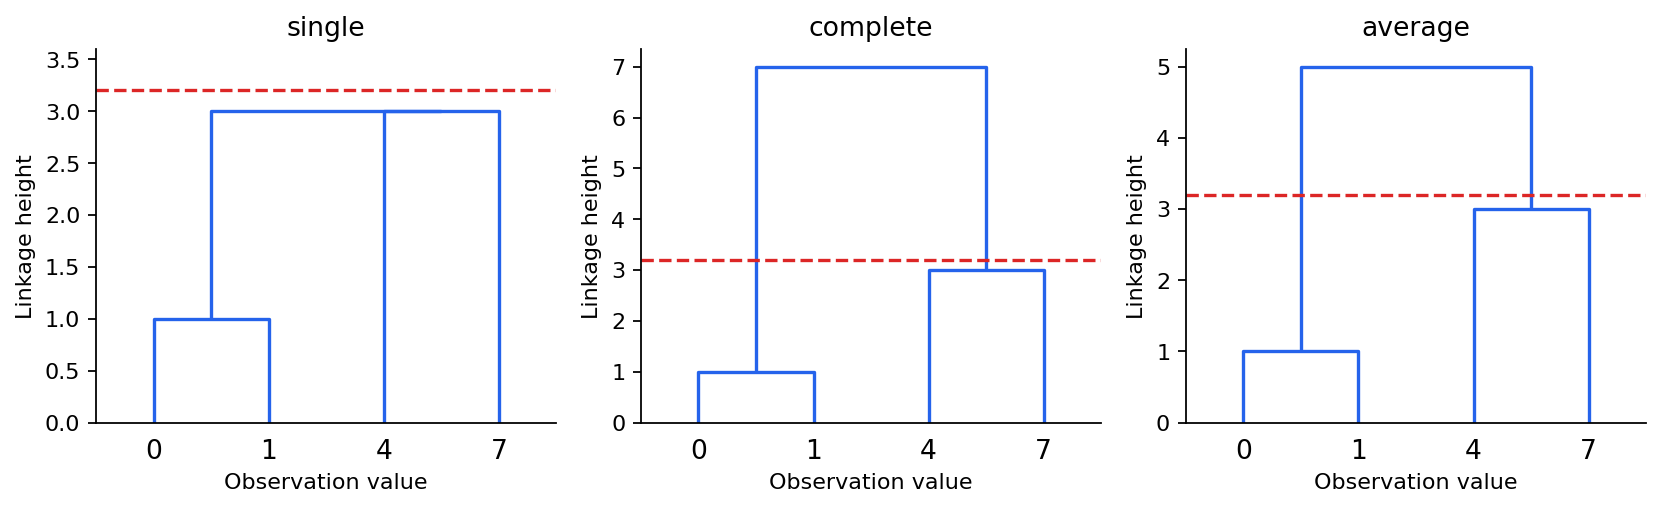

05_core_and_neighbor_distance.png


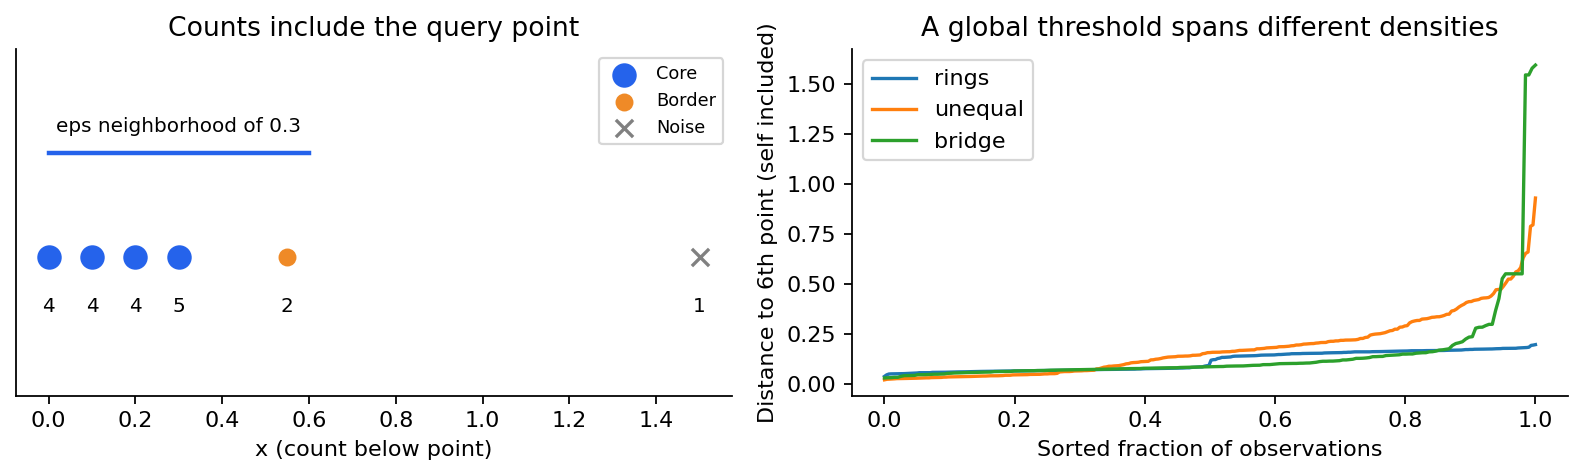

06_unequal_density_sweep.png


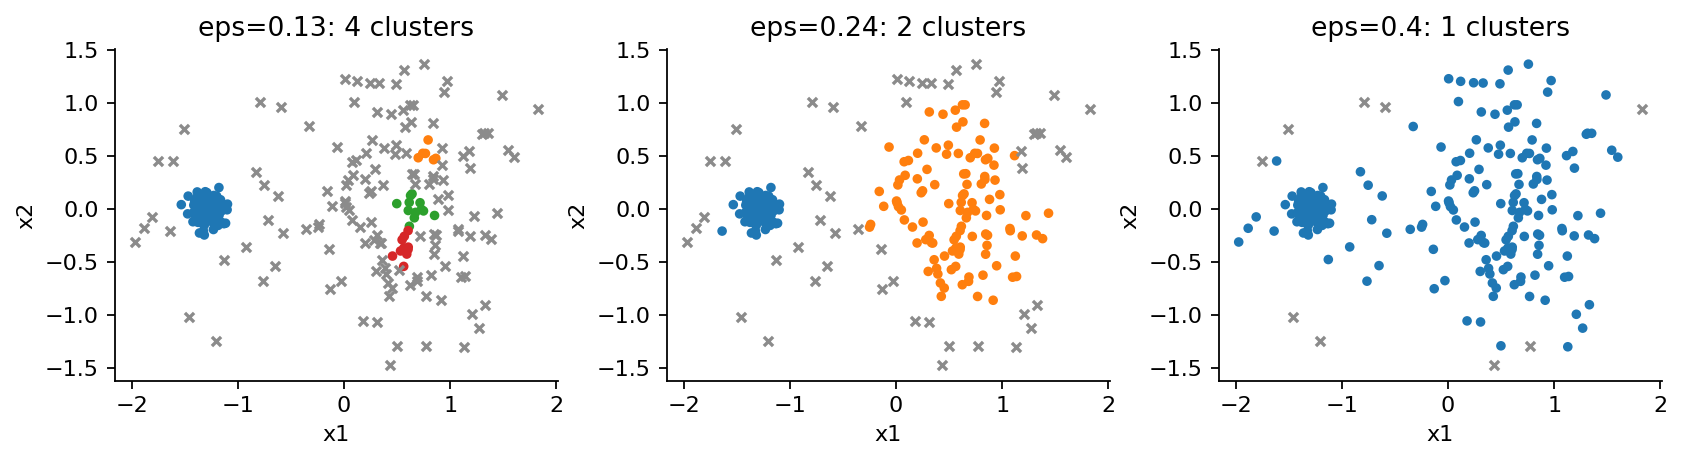

In [6]:
from plots import make
figure_dir = ROOT / 'outputs/notebook-figures'
make(report, figure_dir)
for filename in sorted(figure_dir.glob('*.png')):
    print(filename.name)
    display(Image(filename=str(filename)))

## 独立验收
显式检查在Python优化模式下也不会消失；命令行另提供-O运行报告。

In [7]:
from test_experiment import CHECKS, common_checks, specific
CHECKS.clear()
verified_data = common_checks(report)
specific(report, verified_data)
print('Passed explicit checks:', len(CHECKS))

Passed explicit checks: 224


## 结论
把结果写成带条件的陈述：说明距离、参数、失败机制和未验证之处。更多解释与练习答案见同目录讲义、实验和答案文档。